# *Fundamentals of Data Visualization* 원칙

Claus O. Wilke의 원칙을 반영합니다.

- **색은 데이터를 인코딩할 때만** 쓴다 (장식용 무지개·불필요한 채도 남용 금지).
- **동일 범주 → 동일 색**: `issue_category`, `check_type` 등은 노트북 전체에서 **같은 색 매핑**을 유지한다.
- **색각 이상 친화**: Okabe–Ito 팔레트(논문·교재에서 널리 쓰는 조합)로 범주를 구분한다.
- **강조는 절제**: 한 그래프에서 눈에 띄게 할 요소만 **vermillion(`#D55E00`)** 등으로 강조한다.
- **연속형·분포**: 단일 색조(청색 계열)의 농도·투명도로 표현한다.
- **Data-ink**: 기본적으로 상·우 spine 제거, 격자는 읽기에 필요한 축에만.


In [2]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

# Google Drive 연동

In [3]:
# ── Seaborn ───────────────────────────────────────────────────────
# 통계 그래프·테마

"""
시각화 공통: 폰트, Wilke/Okabe-Ito 색 체계, 범주→색 고정 매핑
(이 셀은 이후 모든 차트에서 재사용하는 상수·함수·데이터 로드를 한 번에 둡니다.)
"""
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# ── 나눔고딕 폰트 설정 (matplotlib + seaborn 동시 적용) ───────────
def set_nanum_gothic():
    if platform.system() == "Windows":
        font_name = "Malgun Gothic"
    else:
        nanum_fonts = [
            f for f in fm.findSystemFonts(fontpaths=None, fontext="ttf")
            if "NanumGothic" in f and "Bold" not in f and "ExtraBold" not in f
        ]
        if nanum_fonts:
            prop = fm.FontProperties(fname=nanum_fonts[0])
            font_name = prop.get_name()
            fm.fontManager.addfont(nanum_fonts[0])
        else:
            print("NanumGothic 폰트를 찾을 수 없습니다. 위 설치 셀 주석을 해제하고 런타임을 재시작하세요.")
            font_name = "DejaVu Sans"

    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return font_name

FONT_NAME = set_nanum_gothic()
print(f"적용 폰트: {FONT_NAME}")

# ── Okabe-Ito 팔레트 ──────────────────────────────────────────────
PALETTE_OI = [
    "#E69F00",  # 주황
    "#56B4E9",  # 하늘색
    "#009E73",  # 녹색
    "#F0E442",  # 노랑
    "#0072B2",  # 파랑
    "#D55E00",  # vermillion
    "#CC79A7",  # 자주
    "#000000",  # 검정
]
COLOR_SEQ         = "#0072B2"
COLOR_NEUTRAL_BAR = "#B0B0B0"
COLOR_EMPHASIS    = "#D55E00"
COLOR_TEXT        = "#2E2E2E"

sns.set_theme(
    style="ticks",
    context="notebook",
    font=FONT_NAME,
    rc={
        "font.family":        FONT_NAME,
        "font.sans-serif":    [FONT_NAME, "DejaVu Sans"],
        "axes.unicode_minus": False,
    },
)
sns.set_palette(PALETTE_OI)

# ── 데이터 로드 ───────────────────────────────────────────────────
tips = sns.load_dataset("tips")
SOURCE_LINE = "출처: seaborn tips dataset"  # ← tips 기준으로 변경

# ── 범주 색 고정 매핑 ─────────────────────────────────────────────
COLOR_BY_DAY    = stable_cat_colors(tips["day"])     # 요일별
COLOR_BY_TIME   = stable_cat_colors(tips["time"])    # 식사시간대별
COLOR_BY_SEX    = stable_cat_colors(tips["sex"])     # 성별
COLOR_BY_SMOKER = stable_cat_colors(tips["smoker"])  # 흡연여부별

# ── 유틸 함수 ────────────────────────────────────────────────────
def stable_cat_colors(values, palette=PALETTE_OI):
    """범주 이름 정렬 순으로 색을 고정 (차트 간 일관성)."""
    cats = sorted(pd.Series(values).dropna().unique())
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def spine_clean(ax, grid_x=False, grid_y=False):
    """Wilke식 Data-ink: 위·오른쪽 축선 제거, 필요한 축만 얇은 격자."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_x:
        ax.grid(True, axis="x", linestyle="--", alpha=0.35, color="#CCCCCC")
    if grid_y:
        ax.grid(True, axis="y", linestyle="--", alpha=0.35, color="#CCCCCC")
    ax.set_axisbelow(True)


def add_footer(fig, caption=None, y_cap=0.085, y_src=0.02, tight_rect=None):
    """캡션 + 데이터 출처를 figure 하단에 고정 배치."""
    if tight_rect is None:
        tight_rect = [0, 0.18, 1, 0.95]
    fig.tight_layout(rect=tight_rect)
    if caption:
        fig.text(0.5, y_cap, caption, ha="center", fontsize=9, style="italic", color=COLOR_TEXT)
    fig.text(0.99, y_src, SOURCE_LINE, ha="right", fontsize=8, color="#666666")


print("shape:", tips.shape)
print("\n자료형 확인:")
print(tips.dtypes)
tips.head()

적용 폰트: NanumGothicCoding
shape: (244, 7)

자료형 확인:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 시각화를 통한 자료의 요약

## 1. 자료의 형태 확인
- tips 컬럼을 수치형(연속/이산)·범주형(명목/순위)으로 분류한다.

In [4]:
print("=" * 45)
print("[ 수치형 자료 ]")
print("  연속형 : total_bill, tip  (소수점 연속값)")
print("  이산형 : size             (1~6명, 셀 수 있음)")
print("\n[ 범주형 자료 ]")
print("  명목형 : sex, smoker, time  (순서 의미 없음)")
print("  순위형 : day               (Thur < Fri < Sat < Sun)")
print("=" * 45)

for col in ["sex", "smoker", "day", "time"]:
    print(f"  {col}: {tips[col].unique().tolist()}")

[ 수치형 자료 ]
  연속형 : total_bill, tip  (소수점 연속값)
  이산형 : size             (1~6명, 셀 수 있음)

[ 범주형 자료 ]
  명목형 : sex, smoker, time  (순서 의미 없음)
  순위형 : day               (Thur < Fri < Sat < Sun)
  sex: ['Female', 'Male']
  smoker: ['No', 'Yes']
  day: ['Sun', 'Sat', 'Thur', 'Fri']
  time: ['Dinner', 'Lunch']


## 2. 범주형 자료 요약 — 도수분포표
- value_counts()로 도수·상대도수, pd.crosstab()으로 교차표를 만든다.

In [5]:
# 도수: 각 범주에 속하는 관측값 개수
print("[ 요일별 도수 ]")
print(tips["day"].value_counts())

# 상대도수: 도수 ÷ 전체 개수
print("\n[ 요일별 상대도수 ]")
print(tips["day"].value_counts(normalize=True).round(3))

# 한 범주 도수분포표
print("\n[ 성별 도수분포표 ]")
print(pd.crosstab(index=tips["sex"], columns="count"))

# 두 범주 교차표: 요일 × 흡연여부가 동시에 만족하는 도수
print("\n[ 요일 × 흡연여부 교차표 ]")
print(pd.crosstab(index=tips["day"], columns=tips["smoker"]))

[ 요일별 도수 ]
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

[ 요일별 상대도수 ]
day
Sat     0.357
Sun     0.311
Thur    0.254
Fri     0.078
Name: proportion, dtype: float64

[ 성별 도수분포표 ]
col_0   count
sex          
Male      157
Female     87

[ 요일 × 흡연여부 교차표 ]
smoker  Yes  No
day            
Thur     17  45
Fri      15   4
Sat      42  45
Sun      19  57


## 3. 범주형 자료 시각화 — 원형 & 막대 그래프
- 원형(Pie): 전체 대비 비율 파악에 유리, 범주 간 크기 비교는 어려움
- 막대(Bar): 도수 크기 비교에 유리, 전체 비율 파악은 어려움

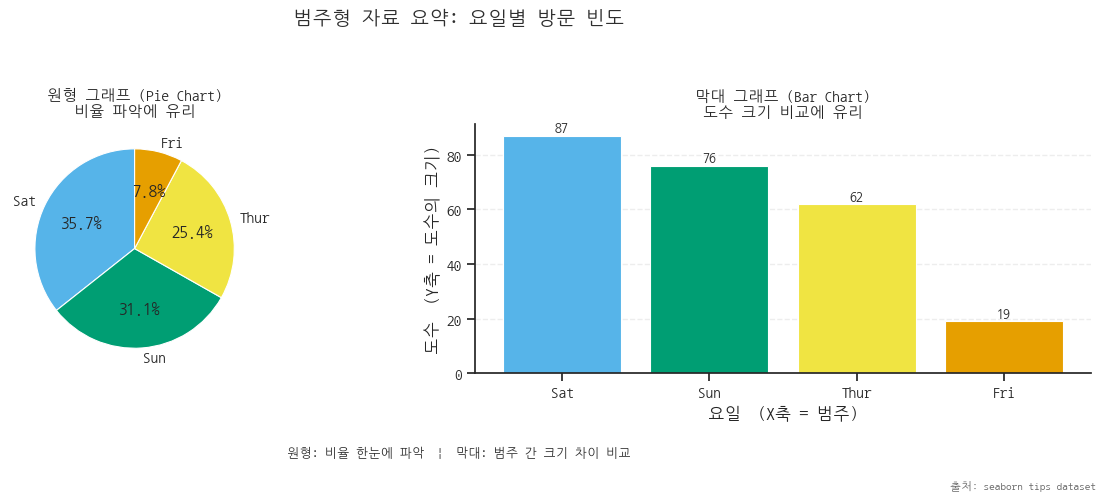

In [6]:
freq_day = tips["day"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("범주형 자료 요약: 요일별 방문 빈도",
             fontsize=14, fontweight="bold", color=COLOR_TEXT)

# ── 원형 그래프 ──────────────────────────────────────────────────
axes[0].pie(
    freq_day,
    labels=freq_day.index,
    autopct="%1.1f%%",                          # 조각마다 퍼센트 표시
    startangle=90,                              # 12시 방향부터 시작
    colors=[COLOR_BY_DAY[d] for d in freq_day.index],
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
)
axes[0].set_title("원형 그래프 (Pie Chart)\n비율 파악에 유리", fontsize=11)

# ── 막대 그래프 ──────────────────────────────────────────────────
bar_colors = [COLOR_BY_DAY[d] for d in freq_day.index]
axes[1].bar(freq_day.index, freq_day.values,
            color=bar_colors, edgecolor="white", linewidth=0.8)

# 막대 위 도수 레이블
for i, val in enumerate(freq_day.values):
    axes[1].text(i, val + 0.5, str(val),
                 ha="center", va="bottom", fontsize=10, color=COLOR_TEXT)

axes[1].set_xlabel("요일  (X축 = 범주)")
axes[1].set_ylabel("도수  (Y축 = 도수의 크기)")
axes[1].set_title("막대 그래프 (Bar Chart)\n도수 크기 비교에 유리", fontsize=11)
spine_clean(axes[1], grid_y=True)

add_footer(fig,
           caption="원형: 비율 한눈에 파악  |  막대: 범주 간 크기 차이 비교",
           tight_rect=[0, 0.12, 1, 0.93])
plt.show()

## 4. 수치형 자료 요약 — 연속형 도수분포표
- 연속형 자료는 구간(계급)으로 나눠 도수를 집계한다.
- 작성 순서: ① 범위 → ② 계급폭 → ③ 계급구간 → ④ 도수 → ⑤ 상대도수

In [7]:
col  = "total_bill"
data = tips[col].dropna()

# ① 자료의 범위
d_min, d_max = data.min(), data.max()
d_range      = d_max - d_min
print(f"최솟값: {d_min:.2f}  최댓값: {d_max:.2f}  범위: {d_range:.2f}")

# ② 계급 수·폭  (Sturges 공식: k = 1 + log2(n))
n_class     = int(np.ceil(1 + np.log2(len(data))))
class_width = np.ceil(d_range / n_class)
print(f"계급 수: {n_class}  계급폭: {class_width}")

# ③ 계급구간 경계점
bins   = np.arange(d_min - 0.5, d_max + class_width, class_width)
labels = [f"{b:.0f}~{b+class_width:.0f}" for b in bins[:-1]]

# ④⑤ 도수 & 상대도수
freq, edges = np.histogram(data, bins=bins)
rel_freq    = freq / freq.sum()

freq_table = pd.DataFrame({
    "계급구간": labels[:len(freq)],
    "도수":     freq,
    "상대도수": rel_freq.round(3),
    "누적도수": freq.cumsum(),
})
print("\n[ total_bill 도수분포표 ]")
print(freq_table.to_string(index=False))

최솟값: 3.07  최댓값: 50.81  범위: 47.74
계급 수: 9  계급폭: 6.0

[ total_bill 도수분포표 ]
 계급구간  도수  상대도수  누적도수
  3~9  10 0.041    10
 9~15  67 0.275    77
15~21  78 0.320   155
21~27  41 0.168   196
27~33  24 0.098   220
33~39  12 0.049   232
39~45   7 0.029   239
45~51   4 0.016   243
51~57   1 0.004   244


## 5. 수치형 자료 시각화 — 히스토그램 & 도수다각형

- 히스토그램: 계급구간×빈도 막대, 단일 분포 형태 파악
- 도수다각형: 계급 중앙점 꺾은선, 여러 그룹 비교에 유리

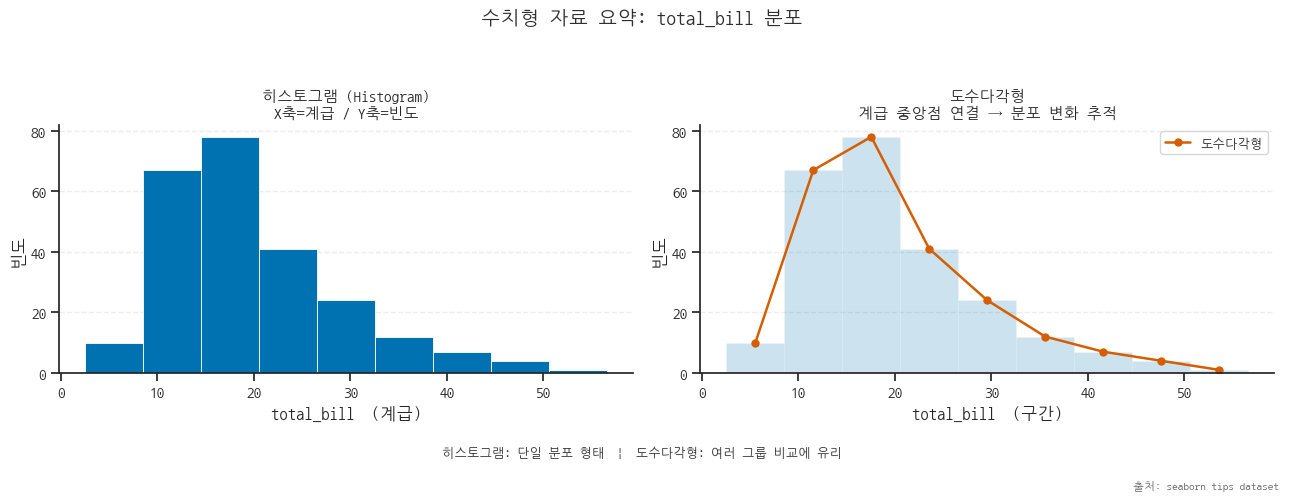

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("수치형 자료 요약: total_bill 분포",
             fontsize=14, fontweight="bold", color=COLOR_TEXT)

# ── 히스토그램 ──────────────────────────────────────────────────
counts, bin_edges, _ = axes[0].hist(
    data, bins=bins,
    color=COLOR_SEQ, edgecolor="white", linewidth=0.6,
)
axes[0].set_title("히스토그램 (Histogram)\nX축=계급 / Y축=빈도", fontsize=11)
axes[0].set_xlabel("total_bill  (계급)")
axes[0].set_ylabel("빈도")
spine_clean(axes[0], grid_y=True)

# ── 도수다각형 ──────────────────────────────────────────────────
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2    # 각 계급의 중앙값

axes[1].hist(data, bins=bins,
             color=COLOR_SEQ, alpha=0.20,
             edgecolor="white", linewidth=0.6)       # 히스토그램 배경
axes[1].plot(bin_mids, counts,
             color=COLOR_EMPHASIS,
             marker="o", markersize=5, linewidth=1.8,
             label="도수다각형")
axes[1].set_title("도수다각형\n계급 중앙점 연결 → 분포 변화 추적", fontsize=11)
axes[1].set_xlabel("total_bill  (구간)")
axes[1].set_ylabel("빈도")
axes[1].legend(fontsize=9)
spine_clean(axes[1], grid_y=True)

add_footer(fig,
           caption="히스토그램: 단일 분포 형태  |  도수다각형: 여러 그룹 비교에 유리",
           tight_rect=[0, 0.12, 1, 0.93])
plt.show()

## 6. 도수다각형 — 두 그룹 비교 (흡연 여부)
- 여러 그룹의 분포를 겹쳐 비교할 때는 히스토그램보다 도수다각형이 적합하다.

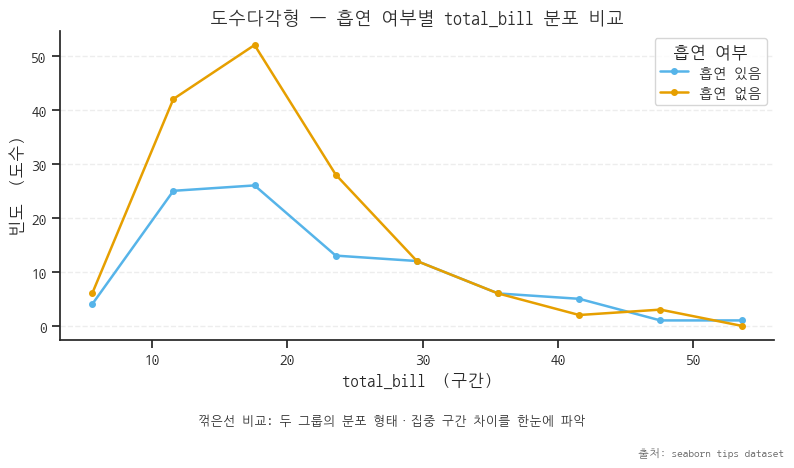

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for label in ["Yes", "No"]:
    subset      = tips.loc[tips["smoker"] == label, "total_bill"].dropna()
    cnt, edg    = np.histogram(subset, bins=bins)
    mids        = (edg[:-1] + edg[1:]) / 2
    g_color     = COLOR_BY_SMOKER[label]
    kor_label   = "흡연 있음" if label == "Yes" else "흡연 없음"
    ax.plot(mids, cnt,
            marker="o", markersize=4, linewidth=1.8,
            color=g_color, label=kor_label)

ax.set_title("도수다각형 — 흡연 여부별 total_bill 분포 비교",
             fontsize=13, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("total_bill  (구간)")
ax.set_ylabel("빈도  (도수)")
ax.legend(title="흡연 여부", fontsize=10)
spine_clean(ax, grid_y=True)

add_footer(fig,
           caption="꺾은선 비교: 두 그룹의 분포 형태·집중 구간 차이를 한눈에 파악",
           tight_rect=[0, 0.12, 1, 0.95])
plt.show()

## 7. 두 변수 자료 요약 — 산점도
- 수치형 × 수치형의 관계(방향·강도)를 파악한다.
- 색(hue)으로 제3변수를 추가해 다변량 정보를 압축한다.

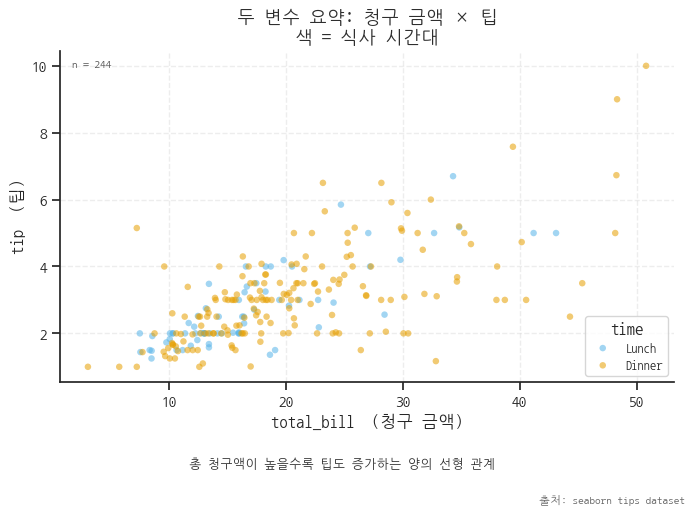

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for time_val in ["Lunch", "Dinner"]:
    sub = tips[tips["time"] == time_val]
    ax.scatter(
        sub["total_bill"], sub["tip"],
        alpha=0.55, s=22,
        color=COLOR_BY_TIME[time_val],
        edgecolors="none",
        label=time_val,
    )

ax.set_title("두 변수 요약: 청구 금액 × 팁\n색 = 식사 시간대",
             fontsize=13, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("total_bill  (청구 금액)")
ax.set_ylabel("tip  (팁)")
ax.legend(title="time", fontsize=9)
ax.text(0.02, 0.97, f"n = {len(tips):,}",
        transform=ax.transAxes, va="top", fontsize=8, color="#555555")
spine_clean(ax, grid_x=True, grid_y=True)

add_footer(fig,
           caption="총 청구액이 높을수록 팁도 증가하는 양의 선형 관계",
           tight_rect=[0, 0.12, 1, 0.95])
plt.show()

# 논리적인 자료의 요약
## 왜 수치로 요약하는가?

히스토그램이나 도수분포표 같은 **그림/도표**는 분포를 직관적으로 보여주지만 두 가지 한계가 있습니다.

1. **일관성·객관성 부족** — 작성자의 주관적 판단에 따라 결과가 달라집니다.  
2. **이론적 근거 제시 어려움** — 시각 자료만으로는 통계적 검정이나 수식 전개가 불가능합니다.

이를 보완하기 위해 **많은 양의 자료를 의미 있는 수치로 요약**하여 분포 상태를 파악합니다.

수치 요약은 크게 네 가지 주제로 구성됩니다.

| 주제 | 핵심 질문 | 대표 수치 |
|------|-----------|-----------|
| 중심위치의 측도 | 자료의 중심은 어디인가? | 평균, 중앙값, 최빈값 |
| 퍼진 정도의 측도 | 자료가 얼마나 흩어져 있는가? | 분산, 표준편차, IQR |
| 도수분포표 요약 | 그룹화된 자료를 어떻게 요약하는가? | 가중평균, 그룹분산 |
| 두 변수 자료 요약 | 두 변수는 어떤 관계인가? | 분할표, 공분산, 상관계수 |

> 이 노트북은 `seaborn`의 내장 데이터셋 **tips**를 사용합니다.  
> tips 데이터는 레스토랑에서 수집한 244건의 식사 기록으로,  
> `total_bill`(청구금액), `tip`(팁), `sex`, `smoker`, `day`, `time`, `size` 컬럼을 포함합니다.

## 1. 중심위치의 측도 (Measure of Center)

자료 전체를 하나의 수치로 대표할 때 사용하는 값입니다.  
중심위치 측도에는 **평균**, **중앙값**, **최빈값** 세 가지가 있습니다.

---

### 1-1. 평균 (Mean)

$$\bar{x} = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

- 모든 관측값의 **산술평균**으로, 관측값을 빠짐없이 반영합니다.
- 통계에서 가장 많이 사용되는 기초 수치입니다.
- **단점**: 극단적으로 크거나 작은 값(이상값)의 영향을 강하게 받습니다.  
  예) 연봉 데이터에 CEO 연봉이 포함되면 평균이 크게 올라갑니다.
- Python: `np.mean()`

---

### 1-2. 중앙값 (Median)

관측값을 크기 순서대로 정렬했을 때 **정 가운데 위치**하는 값입니다.

- **n이 홀수**일 때: $\frac{n+1}{2}$ 번째 관측값
- **n이 짝수**일 때: $\frac{n}{2}$ 번째와 $\frac{n}{2}+1$ 번째 관측값의 평균

> 중앙값은 가운데 위치한 값만 중요하며,  
> 나머지 값의 크기가 아무리 바뀌어도 중앙값은 변하지 않습니다.  
> 따라서 **극단값(이상값)의 영향을 받지 않습니다**.

- Python: `np.median()`

---

### 1-3. 최빈값 (Mode)

관측값 중 **가장 자주 나오는 값**입니다.

- 이산형 또는 범주형 자료에서 주로 사용합니다.
- 연속형 자료에서는 같은 값이 반복되는 경우가 드물어 사용하기 어렵습니다.
- **단봉형 분포**에서만 의미 있는 중심위치 측도가 됩니다.  
  이봉형(두 개의 봉우리) 이상의 분포에서는 최빈값이 중심을 나타내지 못합니다.
- Python: `scipy.stats.mode()`

---

### 어떤 것을 선택해야 할까?

| 상황 | 권장 측도 |
|------|-----------|
| 극단값이 없는 대칭 분포 | 평균 (= 중앙값 = 최빈값) |
| 극단값이 있는 비대칭 분포 | **중앙값** (극단값 영향 배제) |
| 전체 관측값을 모두 반영하고 싶을 때 | **평균** |
| 이산형/범주형 자료 | **최빈값** |

> **비대칭 분포에서의 관계**  
> - 왼쪽으로 치우친 분포(right-skewed): 평균 > 중앙값  
> - 오른쪽으로 치우친 분포(left-skewed): 평균 < 중앙값

=== total_bill 중심위치 ===
  평균(mean)   : 19.79
  중앙값(median): 17.80
  최빈값(mode)  : 13.42

※ mean > median → 오른쪽으로 치우친 분포(right-skewed)


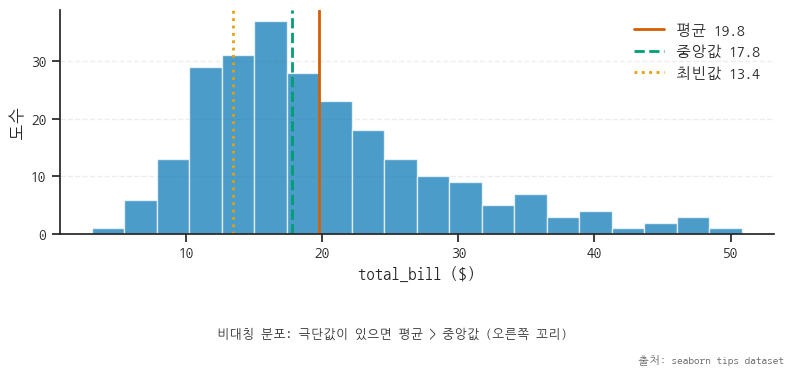

In [12]:
from scipy import stats

# ── 1. 중심위치의 측도 ────────────────────────────────────────────

"""
평균(mean)   : 모든 관측값의 합 / 개수 → 극단값에 민감
중앙값(median): 정렬 후 가운데 값      → 극단값에 강건
최빈값(mode)  : 가장 자주 나오는 값    → 이산/범주형에 적합
"""

col = tips["total_bill"]

mean_val   = np.mean(col)
median_val = np.median(col)
mode_val   = stats.mode(col, keepdims=True).mode[0]

print("=== total_bill 중심위치 ===")
print(f"  평균(mean)   : {mean_val:.2f}")
print(f"  중앙값(median): {median_val:.2f}")
print(f"  최빈값(mode)  : {mode_val:.2f}")
print()
print("※ mean > median → 오른쪽으로 치우친 분포(right-skewed)")

# ── 시각화 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(col, bins=20, color=COLOR_SEQ, alpha=0.7, edgecolor="white")
ax.axvline(mean_val,   color=PALETTE_OI[5], lw=2, ls="-",  label=f"평균 {mean_val:.1f}")
ax.axvline(median_val, color=PALETTE_OI[2], lw=2, ls="--", label=f"중앙값 {median_val:.1f}")
ax.axvline(mode_val,   color=PALETTE_OI[0], lw=2, ls=":",  label=f"최빈값 {mode_val:.1f}")

ax.set_xlabel("total_bill ($)")
ax.set_ylabel("도수")
ax.legend(frameon=False)
spine_clean(ax, grid_y=True)
add_footer(fig,
           caption="비대칭 분포: 극단값이 있으면 평균 > 중앙값 (오른쪽 꼬리)",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 2. 퍼진 정도의 측도 (Measure of Dispersion)

중심위치 측도만으로는 분포를 완전히 파악할 수 없습니다.  
평균이 같아도 데이터가 얼마나 몰려 있는지, 얼마나 흩어져 있는지는  
**퍼진 정도의 측도**가 있어야 알 수 있습니다.

> 예) A반 시험 점수: 70, 70, 70 → 평균 70, 표준편차 0  
>     B반 시험 점수: 40, 70, 100 → 평균 70, 표준편차 30  
>     두 반의 평균은 같지만 실력 분포는 전혀 다릅니다.

---

### 2-1. 분산 (Variance)

각 관측값이 평균으로부터 **얼마나 떨어져 있는지**를 나타냅니다.

편차(deviation)의 합은 항상 0이므로 → 편차를 **제곱**하여 양수로 만든 뒤 평균을 구합니다.

$$s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

> 분모를 $n$ 대신 $n-1$로 나누는 이유:  
> 표본에서 모분산을 추정할 때 편향(bias)을 제거하기 위함입니다 (불편추정량).

- **단점**: 단위가 원래 변수 단위의 **제곱**이므로 직접 해석하기 어렵습니다.
- Python: `np.var(col, ddof=1)`

---

### 2-2. 표준편차 (Standard Deviation)

분산의 **양의 제곱근**을 취하여 원래 변수와 단위를 맞춥니다.

$$s = \sqrt{s^2}$$

- 관측값과 **같은 단위**를 가지므로 해석이 직관적입니다.
- 평균과 함께 사용하면 "평균 ± 표준편차" 범위 안에 약 68%의 데이터가 있음을 알 수 있습니다 (정규분포 가정 시).
- Python: `np.std(col, ddof=1)`

---

### 2-3. 범위 (Range)

$$\text{Range} = \max - \min$$

- 계산이 간단하고 해석이 쉽습니다.
- **단점**: 중간값들을 전혀 고려하지 않고, 극단값 하나만 있어도 크게 변합니다.
- Python: `np.max(col) - np.min(col)`

---

### 2-4. 사분위수 범위 (IQR, Interquartile Range)

$$\text{IQR} = Q_3 - Q_1$$

전체 자료를 4등분하는 **사분위수** Q1(25%), Q2(50%), Q3(75%)를 이용합니다.

- IQR은 **중간 50% 데이터의 범위**로, 극단값의 영향을 받지 않습니다.
- 중앙값의 특성(극단값에 강건함) = 사분위수 범위의 특성
- Python: `np.percentile(col, [25, 75])`

---

### 2-5. 변동계수 (CV, Coefficient of Variation)

$$CV = \frac{s}{\bar{x}} \times 100 \quad (\%)$$

- 표준편차를 평균으로 나눈 **상대적 퍼진 정도**입니다.
- **단위가 없기 때문에** 서로 다른 단위를 가진 변수끼리 산포도를 비교할 수 있습니다.  
  예) 키(cm)와 몸무게(kg)의 변동성을 비교할 때 유용합니다.

---

### 세 가지 퍼진 정도 측도 비교

| 측도 | 특징 | 단점 |
|------|------|------|
| 표준편차 | 모든 관측값 반영, 평균과 짝을 이룸 | 극단값에 민감 |
| IQR | 극단값 영향 없음, 중앙값과 짝을 이룸 | Q1~Q3 사이 분포 반영 안 함 |
| 범위 | 가장 단순 | 표준편차와 IQR의 단점을 모두 가짐 |

=== total_bill 퍼진 정도 ===
  분산(variance)    : 79.25
  표준편차(std)     : 8.90
  범위(range)       : 47.74
  IQR               : 10.78  (Q1=13.35, Q3=24.13)
  변동계수(CV)      : 45.0%


/tmp/ipykernel_5002/913530473.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for day, grp in tips.groupby("day")["total_bill"]:
/tmp/ipykernel_5002/913530473.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_std = tips.groupby("day")["total_bill"].std().reindex(["Thur","Fri","Sat","Sun"])


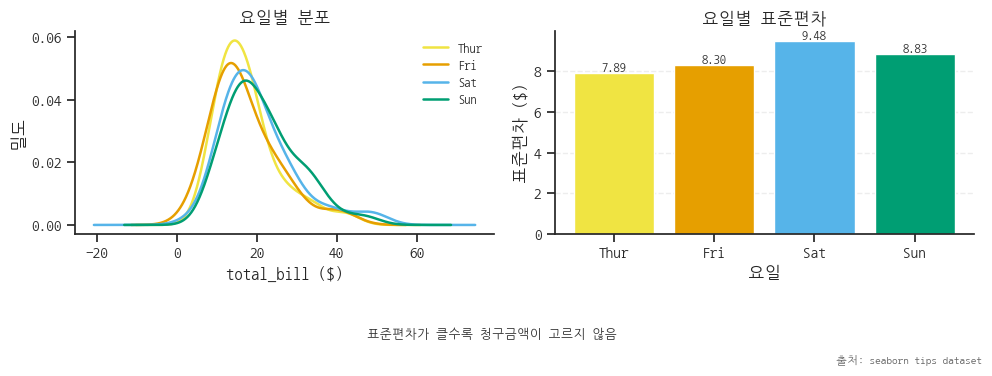

In [13]:
# ── 2. 퍼진 정도의 측도 ──────────────────────────────────────────
"""
분산(variance) s²  = Σ(xi - x̄)² / n
표준편차(std)  s   = √s²          (단위가 원래 변수와 같음)
범위(range)        = max - min
사분위수범위(IQR)  = Q3 - Q1      (극단값 영향 없음)
변동계수(CV)       = s / x̄ × 100  (단위 없음 → 서로 다른 변수 비교 가능)
"""

col = tips["total_bill"]
n   = len(col)

var_val  = np.var(col, ddof=1)         # 표본분산 (n-1)
std_val  = np.std(col, ddof=1)
rng_val  = np.max(col) - np.min(col)
q1, q3   = np.percentile(col, [25, 75])
iqr_val  = q3 - q1
cv_val   = std_val / np.mean(col) * 100

print("=== total_bill 퍼진 정도 ===")
print(f"  분산(variance)    : {var_val:.2f}")
print(f"  표준편차(std)     : {std_val:.2f}")
print(f"  범위(range)       : {rng_val:.2f}")
print(f"  IQR               : {iqr_val:.2f}  (Q1={q1:.2f}, Q3={q3:.2f})")
print(f"  변동계수(CV)      : {cv_val:.1f}%")

# ── 시각화: 요일별 표준편차 비교 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 왼쪽: 요일별 KDE
for day, grp in tips.groupby("day")["total_bill"]:
    grp.plot.kde(ax=axes[0], label=day, color=COLOR_BY_DAY[day], lw=1.8)
axes[0].set_xlabel("total_bill ($)")
axes[0].set_ylabel("밀도")
axes[0].set_title("요일별 분포")
axes[0].legend(frameon=False, fontsize=9)
spine_clean(axes[0])

# 오른쪽: 요일별 표준편차 막대
day_std = tips.groupby("day")["total_bill"].std().reindex(["Thur","Fri","Sat","Sun"])
colors  = [COLOR_BY_DAY[d] for d in day_std.index]
axes[1].bar(day_std.index, day_std.values, color=colors, edgecolor="white")
axes[1].set_xlabel("요일")
axes[1].set_ylabel("표준편차 ($)")
axes[1].set_title("요일별 표준편차")
for x, v in enumerate(day_std.values):
    axes[1].text(x, v + 0.1, f"{v:.2f}", ha="center", fontsize=9, color=COLOR_TEXT)
spine_clean(axes[1], grid_y=True)

add_footer(fig,
           caption="표준편차가 클수록 청구금액이 고르지 않음",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 3. 백분위수와 사분위수

### 백분위수 (Percentile)

중앙값(자료의 50% 위치)을 **일반화한 개념**입니다.

> **제 100×p 백분위수**란?  
> 자료를 오름차순으로 정렬했을 때, 전체 자료의 **p × 100%**가  
> 그 값보다 작거나 같은 위치에 있는 값입니다.

#### 구하는 방법

1. 관측값을 오름차순으로 정렬합니다.
2. 관측값의 개수 $n$에 $p$를 곱합니다.
3. $n \times p$가 **정수**인 경우 → $n \times p$번째와 $n \times p + 1$번째 관측값의 평균
4. $n \times p$가 **정수가 아닌** 경우 → 정수 부분에 1을 더한 값 $m$번째 관측값

---

### 사분위수 (Quartile)

백분위수 중 전체를 **4등분**하는 특별한 값입니다.

| 기호 | 이름 | 백분위수 | 의미 |
|------|------|----------|------|
| $Q_1$ | 제1사분위수 | 제25백분위수 | 하위 25% 위치 |
| $Q_2$ | 제2사분위수 | 제50백분위수 | 중앙값 |
| $Q_3$ | 제3사분위수 | 제75백분위수 | 상위 25% 위치 |

> 중앙값은 전체의 1/2 위치이므로 **제2사분위수 = 제50백분위수**입니다.

- Python: `np.percentile(arr, [25, 50, 75])`

=== 백분위수 ===
  제 10백분위수 : 10.34
  제 25백분위수 : 13.35
  제 50백분위수 : 17.80
  제 75백분위수 : 24.13
  제 90백분위수 : 32.24


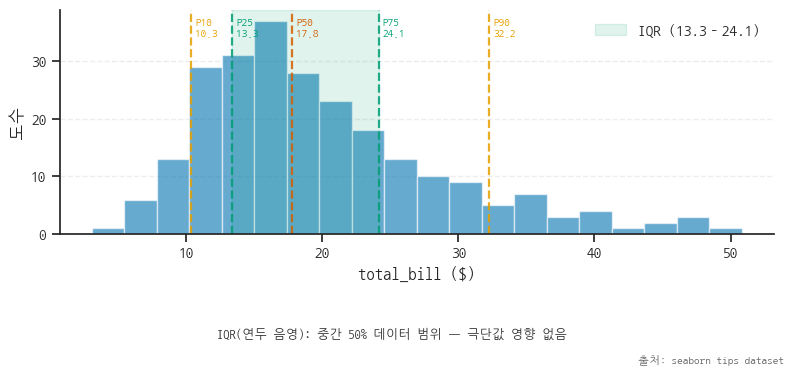

In [14]:
# ── 3. 백분위수 · 사분위수 ───────────────────────────────────────
"""
백분위수(percentile): 자료를 정렬했을 때 백분율로 특정 위치의 값
사분위수: Q1(25%), Q2(50%=중앙값), Q3(75%)
IQR = Q3 - Q1  → 중간 50% 범위
"""

col = tips["total_bill"]
p_vals = [10, 25, 50, 75, 90]
p_results = np.percentile(col, p_vals)

print("=== 백분위수 ===")
for p, v in zip(p_vals, p_results):
    print(f"  제{p:3d}백분위수 : {v:.2f}")

# ── 시각화 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(col, bins=20, color=COLOR_SEQ, alpha=0.6, edgecolor="white")

pct_colors = [PALETTE_OI[0], PALETTE_OI[2], PALETTE_OI[5],
              PALETTE_OI[2], PALETTE_OI[0]]
for p, v, c in zip(p_vals, p_results, pct_colors):
    ax.axvline(v, color=c, lw=1.6, ls="--", alpha=0.85)
    ax.text(v + 0.3, ax.get_ylim()[1] * 0.88,
            f"P{p}\n{v:.1f}", fontsize=8, color=c, ha="left")

# IQR 음영
q1, q3 = np.percentile(col, [25, 75])
ax.axvspan(q1, q3, alpha=0.12, color=PALETTE_OI[2], label=f"IQR ({q1:.1f}–{q3:.1f})")
ax.set_xlabel("total_bill ($)")
ax.set_ylabel("도수")
ax.legend(frameon=False)
spine_clean(ax, grid_y=True)
add_footer(fig,
           caption="IQR(연두 음영): 중간 50% 데이터 범위 — 극단값 영향 없음",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 4. 상자그림 (Box-Whisker Plot)

상자그림은 다섯 가지 요약 수치를 **하나의 그림**으로 표현합니다.

$$\text{최솟값} \quad Q_1 \quad Q_2(\text{중앙값}) \quad Q_3 \quad \text{최댓값}$$

### 구성 요소

| 요소 | 설명 |
|------|------|
| **상자(box)** | $Q_1$부터 $Q_3$까지, 즉 IQR 범위를 나타냅니다 |
| **상자 내 선** | $Q_2$ (중앙값) 위치를 표시합니다 |
| **수염(whisker)** | $Q_1 - 1.5 \times IQR$ ~ $Q_3 + 1.5 \times IQR$ 범위까지 연장됩니다 |
| **이상값(outlier)** | 수염 바깥에 위치한 점으로 표시됩니다 |

> 수염의 길이가 길면 → 데이터가 넓게 분포  
> 상자의 위아래 크기가 다르면 → 분포가 비대칭

---

### 상자그림의 특징

- 일반 그래프에서 드러나지 않는 **이상값, 분포의 대칭성, 퍼진 정도**를 한눈에 파악합니다.
- **봉우리가 하나**인 단봉형 분포에서 효과적입니다.
- 봉우리가 여러 개인 다봉형 분포에서는 분포의 형태를 잘 표현하지 못합니다.
- 따라서 상자그림을 그리기 전에 **히스토그램으로 분포 형태를 먼저 확인**하는 것이 좋습니다.

---

### 상자그림으로 그룹 비교하기

여러 그룹의 상자그림을 나란히 그리면 다음을 한눈에 비교할 수 있습니다.

- 각 그룹의 중앙값 위치 (그룹 간 수준 차이)
- 각 그룹의 IQR 크기 (그룹 간 산포 차이)
- 이상값의 존재 여부

- Python: `plt.boxplot()` 또는 `sns.boxplot()`

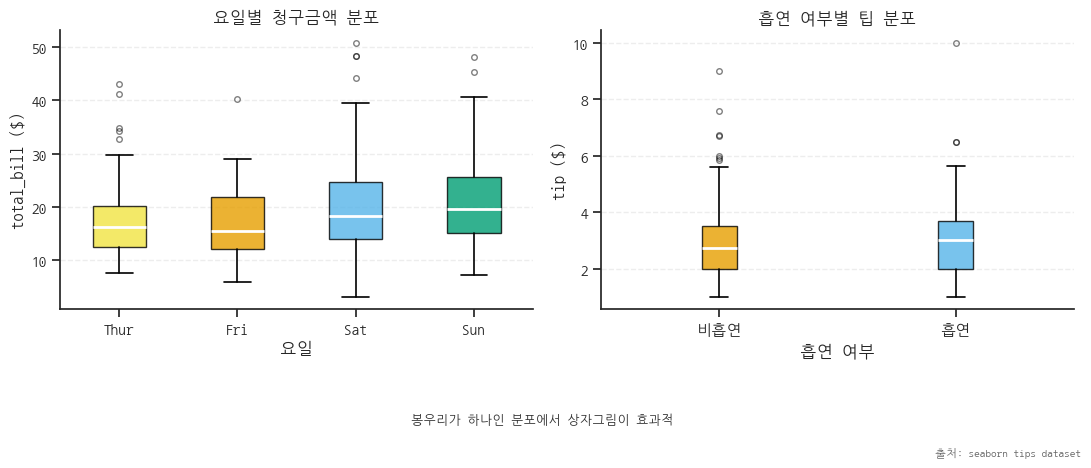

In [17]:
# ── 4. 상자그림 ──────────────────────────────────────────────────
"""
상자그림 5가지 요약 수치: 최솟값, Q1, Q2(중앙값), Q3, 최댓값
상자: Q1 ~ Q3 (IQR)
수염: Q1 - 1.5×IQR  ~  Q3 + 1.5×IQR
그 바깥 점: 이상값(outlier)
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 왼쪽: 요일별 total_bill 상자그림
day_order = ["Thur", "Fri", "Sat", "Sun"]
bp = axes[0].boxplot(
    [tips[tips["day"] == d]["total_bill"].values for d in day_order],
    tick_labels=day_order,
    patch_artist=True,
    medianprops=dict(color="white", lw=2),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5)
)
for patch, day in zip(bp["boxes"], day_order):
    patch.set_facecolor(COLOR_BY_DAY[day])
    patch.set_alpha(0.8)
axes[0].set_xlabel("요일")
axes[0].set_ylabel("total_bill ($)")
axes[0].set_title("요일별 청구금액 분포")
spine_clean(axes[0], grid_y=True)

# 오른쪽: 흡연 여부별 tip 상자그림
smoker_order = ["No", "Yes"]
bp2 = axes[1].boxplot(
    [tips[tips["smoker"] == s]["tip"].values for s in smoker_order],
    tick_labels=["비흡연", "흡연"],
    patch_artist=True,
    medianprops=dict(color="white", lw=2),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5)
)
for patch, s in zip(bp2["boxes"], smoker_order):
    patch.set_facecolor(COLOR_BY_SMOKER[s])
    patch.set_alpha(0.8)
axes[1].set_xlabel("흡연 여부")
axes[1].set_ylabel("tip ($)")
axes[1].set_title("흡연 여부별 팁 분포")
spine_clean(axes[1], grid_y=True)

add_footer(fig,
           caption="봉우리가 하나인 분포에서 상자그림이 효과적",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 5. 도수분포표에서의 자료 요약

### 원 자료가 없을 때의 처리

실제 분석 현장에서는 원 자료(raw data)가 아닌  
이미 **그룹화된 도수분포표** 형태로만 자료가 주어지는 경우가 있습니다.  
(예: 통계청 자료, 오래된 보고서 등)

이 경우 다음과 같은 **가정**을 사용합니다.

> **계급구간의 모든 관측값이 그 계급의 중간값(midpoint)을 갖는다고 가정**

---

### 도수분포표에서의 평균

계급의 수 $k$, 각 계급의 도수 $f_i$, 중간값 $m_i$, 자료의 개수 $n = \sum f_i$ 일 때:

$$\bar{x}_g = \frac{1}{n}(m_1 f_1 + m_2 f_2 + \cdots + m_k f_k) = \sum_{i=1}^{k} m_i \cdot \frac{f_i}{n}$$

→ **각 계급의 중간값 × 상대도수**의 합

---

### 도수분포표에서의 분산과 표준편차

$$s_g^2 = \frac{1}{n-1} \sum_{i=1}^{k}(m_i - \bar{x}_g)^2 \cdot f_i$$

$$s_g = \sqrt{s_g^2}$$

---

### 주의사항

> 원 자료를 그룹화하면 **정보가 손실**됩니다.  
> 같은 계급에 속하더라도 실제 값은 제각각이지만,  
> 모두 중간값으로 처리하기 때문에 원 자료로 계산한 값과 차이가 생깁니다.  
> **가능하다면 반드시 원 자료를 사용**하고,  
> 도수분포표 기반 계산은 원 자료를 구할 수 없을 때의 차선책입니다.

---

### Sturges 공식

적절한 계급 수 $k$를 결정하는 경험식입니다.

$$k = 1 + \log_2 n = 1 + 3.322 \log_{10} n$$

- Python: `int(np.ceil(1 + np.log2(n)))`

=== 도수분포표 ===
      계급 구간   중간값  도수(fi)   상대도수  누적상대도수
  3.1 ~ 8.4  5.72       8 0.0328  0.0328
 8.4 ~ 13.7 11.03      59 0.2418  0.2746
13.7 ~ 19.0 16.33      73 0.2992  0.5738
19.0 ~ 24.3 21.64      44 0.1803  0.7541
24.3 ~ 29.6 26.94      25 0.1025  0.8566
29.6 ~ 34.9 32.24      19 0.0779  0.9344
34.9 ~ 40.2 37.55       7 0.0287  0.9631
40.2 ~ 45.5 42.85       5 0.0205  0.9836
45.5 ~ 50.8 48.16       4 0.0164  1.0000

도수분포표 기반 평균 : 19.66  (원 자료 평균: 19.79)
도수분포표 기반 표준편차: 8.95  (원 자료 표준편차: 8.90)
※ 그룹화에 의해 정보가 손실되므로 원 자료 사용 권장


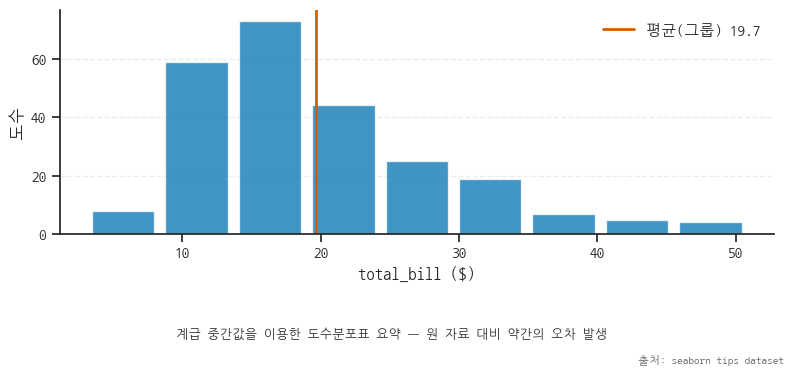

In [18]:
# ── 5. 도수분포표에서의 자료 요약 ────────────────────────────────
"""
원 자료가 없고 그룹화된 자료(도수분포표)만 있을 때:
  - 각 계급의 중간값(midpoint)을 관측값으로 가정
  - 평균 = Σ(중간값 × 상대도수)
  - 분산 = (1/(n-1)) × Σ((중간값 - 평균)² × 도수)
"""

# Sturges 공식으로 계급 구간 생성
col = tips["total_bill"]
k   = int(np.ceil(1 + np.log2(len(col))))          # 계급 수
bins = np.linspace(col.min(), col.max(), k + 1)

counts, edges = np.histogram(col, bins=bins)
midpoints     = (edges[:-1] + edges[1:]) / 2
n             = counts.sum()
rel_freq      = counts / n

freq_table = pd.DataFrame({
    "계급 구간":  [f"{edges[i]:.1f} ~ {edges[i+1]:.1f}" for i in range(k)],
    "중간값":     midpoints.round(2),
    "도수(fi)":   counts,
    "상대도수":   rel_freq.round(4),
    "누적상대도수": rel_freq.cumsum().round(4),
})
print("=== 도수분포표 ===")
print(freq_table.to_string(index=False))

# 도수분포표로 계산한 평균과 분산
mean_g = np.sum(midpoints * rel_freq)
var_g  = (1 / (n - 1)) * np.sum(counts * (midpoints - mean_g) ** 2)
std_g  = np.sqrt(var_g)

print(f"\n도수분포표 기반 평균 : {mean_g:.2f}  (원 자료 평균: {col.mean():.2f})")
print(f"도수분포표 기반 표준편차: {std_g:.2f}  (원 자료 표준편차: {col.std():.2f})")
print("※ 그룹화에 의해 정보가 손실되므로 원 자료 사용 권장")

# ── 시각화 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(midpoints, counts, width=(edges[1]-edges[0])*0.85,
       color=COLOR_SEQ, alpha=0.75, edgecolor="white")
ax.axvline(mean_g, color=PALETTE_OI[5], lw=2, label=f"평균(그룹) {mean_g:.1f}")
ax.set_xlabel("total_bill ($)")
ax.set_ylabel("도수")
ax.legend(frameon=False)
spine_clean(ax, grid_y=True)
add_footer(fig,
           caption="계급 중간값을 이용한 도수분포표 요약 — 원 자료 대비 약간의 오차 발생",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 6. 두 변수 자료의 요약 — 범주형: 분할표

지금까지는 **한 변수**를 요약하는 방법을 배웠습니다.  
이제 **두 변수 이상**을 동시에 분석하는 방법을 학습합니다.

---

### 두 변수 요약의 분류

| 자료 유형 | 요약 방법 |
|-----------|-----------|
| 범주형 × 범주형 | **분할표** (contingency table) |
| 연속형 × 연속형 | 산점도, 공분산, 상관계수 |

---

### 분할표 (Contingency Table)

두 범주형 변수를 **2차원 도수분포표**로 나타낸 것입니다.  
도수분포표를 2차원으로 확장한 형태라고 이해할 수 있습니다.

> 교차하는 각 셀에는 **두 변수의 범주가 동시에 갖는 관측값의 수**가 들어갑니다.

예) 요일(행) × 식사시간(열) 분할표

|  | Dinner | Lunch |
|--|--------|-------|
| Thur | 1 | 61 |
| Fri | 12 | 7 |
| Sat | 87 | 0 |
| Sun | 76 | 0 |

---

### 상대도수 분할표

셀의 값을 **상대도수(비율)**로 변환하면 두 변수 사이의 조건부 분포를 비교할 수 있습니다.

- **행 기준 상대도수**: 각 행의 합이 1 → "해당 요일 방문객 중 식사시간 비율"
- **열 기준 상대도수**: 각 열의 합이 1 → "해당 식사시간 방문객 중 요일 비율"
- **전체 상대도수**: 전체 합이 1

---

### Python 코드

```python
# 도수 분할표
pd.crosstab(index=기준_범주, columns=관측_범주)

# 행 기준 상대도수
pd.crosstab(index=기준_범주, columns=관측_범주, normalize="index")

# 열 기준 상대도수
pd.crosstab(index=기준_범주, columns=관측_범주, normalize="columns")
```


=== 도수 분할표 (요일 × 식사시간) ===
time  Lunch  Dinner
day                
Thur     61       1
Fri       7      12
Sat       0      87
Sun       0      76

=== 행 기준 상대도수(%) ===
time  Lunch  Dinner
day                
Thur   98.4     1.6
Fri    36.8    63.2
Sat     0.0   100.0
Sun     0.0   100.0


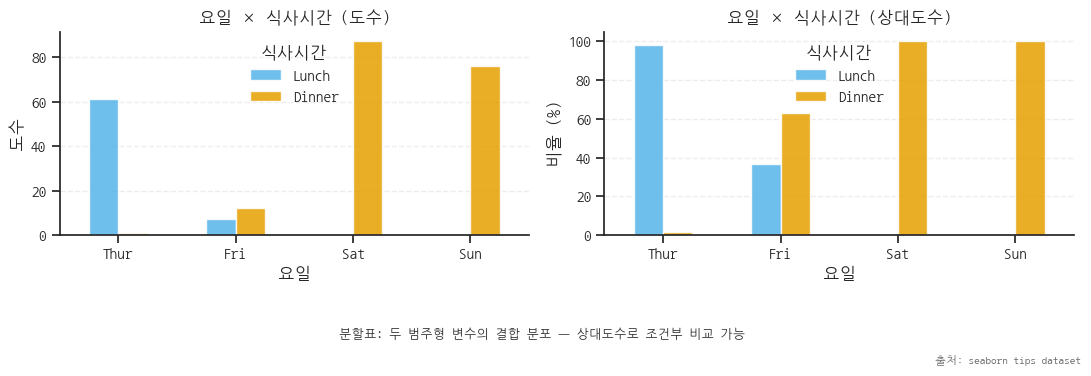

In [19]:
# ── 6. 두 변수 요약 — 분할표 ────────────────────────────────────
"""
범주형 두 변수 동시 요약 → pd.crosstab()
분할표: 두 변수의 범주 조합별 빈도
상대도수로 변환하면 조건부 분포 비교 가능
"""

# 도수 분할표
ct_count = pd.crosstab(tips["day"], tips["time"])
print("=== 도수 분할표 (요일 × 식사시간) ===")
print(ct_count)
print()

# 행 기준 상대도수 (각 요일에서 시간대 비율)
ct_pct = pd.crosstab(tips["day"], tips["time"], normalize="index").round(3) * 100
print("=== 행 기준 상대도수(%) ===")
print(ct_pct)

# ── 시각화: 묶음 막대그래프 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ct_count.plot(kind="bar", ax=axes[0],
              color=[COLOR_BY_TIME[t] for t in ct_count.columns],
              edgecolor="white", alpha=0.85, rot=0)
axes[0].set_xlabel("요일")
axes[0].set_ylabel("도수")
axes[0].set_title("요일 × 식사시간 (도수)")
axes[0].legend(title="식사시간", frameon=False)
spine_clean(axes[0], grid_y=True)

ct_pct.plot(kind="bar", ax=axes[1],
            color=[COLOR_BY_TIME[t] for t in ct_pct.columns],
            edgecolor="white", alpha=0.85, rot=0)
axes[1].set_xlabel("요일")
axes[1].set_ylabel("비율 (%)")
axes[1].set_title("요일 × 식사시간 (상대도수)")
axes[1].legend(title="식사시간", frameon=False)
spine_clean(axes[1], grid_y=True)

add_footer(fig,
           caption="분할표: 두 범주형 변수의 결합 분포 — 상대도수로 조건부 비교 가능",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()

## 7. 두 변수 자료의 요약 — 연속형: 산점도 · 공분산 · 상관계수

### 산점도 (Scatter Plot)

두 연속형 변수의 관측값 쌍 $(x_i, y_i)$을 좌표평면에 점으로 나타낸 그림입니다.

- 두 변수 사이의 관계를 **시각적으로 파악**하는 가장 기본적인 방법입니다.
- 관측값이 많을 경우 점들이 일정한 **띠(band) 형태**를 이룹니다.
- **상관계수를 계산하기 전에 반드시 산점도를 먼저 확인**해야 합니다.
- Python: `plt.scatter()` 또는 `sns.scatterplot()`

---

### 공분산 (Covariance)

두 변수 $x$, $y$가 **서로 어떤 관계를 가지는지** 수치로 나타냅니다.

$$S_{xy} = \frac{1}{n} \sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

- $x$와 $y$가 **같은 방향**으로 변할 때 → 공분산 **양수(+)**
- $x$와 $y$가 **반대 방향**으로 변할 때 → 공분산 **음수(-)**
- **단점**: 단위가 있어서 변수의 스케일에 따라 값이 달라지므로 크기 자체로 해석하기 어렵습니다.
- Python: `dataframe.cov()`

---

### 상관계수 (Correlation Coefficient)

공분산을 두 변수의 표준편차로 나누어 **단위를 없앤** 값입니다.  
피어슨(Pearson)이 제안하여 **피어슨 상관계수**라고도 합니다.

$$r = \frac{S_{xy}}{\sqrt{S_{xx}} \cdot \sqrt{S_{yy}}}$$

여기서 $S_{xx} = \sum(x_i - \bar{x})^2$, $S_{yy} = \sum(y_i - \bar{y})^2$, $S_{xy} = \sum(x_i-\bar{x})(y_i-\bar{y})$

---

### 상관계수의 특징

| 값 범위 | 의미 |
|---------|------|
| $r = +1$ | 모든 점이 기울기 양수인 직선 위에 정확히 위치 |
| $0 < r < 1$ | 양의 선형관계 (값이 클수록 직선에 가까움) |
| $r \approx 0$ | 선형관계 없음 |
| $-1 < r < 0$ | 음의 선형관계 |
| $r = -1$ | 모든 점이 기울기 음수인 직선 위에 정확히 위치 |

- 상관계수는 **단위가 없으므로** 단위가 다른 변수끼리도 직선관계 정도를 비교할 수 있습니다.
- Python: `dataframe.corr()`

---

### 상관계수와 인과관계

> **상관계수가 높다 ≠ 인과관계가 있다**

여름에 상어에 물리는 사고 횟수와 아이스크림 판매량은 높은 양의 상관관계를 보입니다.  
하지만 두 변수 모두 **"여름"이라는 공통 원인**에 의해 증가한 것이며,  
아이스크림이 상어 사고를 유발하는 것이 아닙니다.

이처럼 직접적인 인과관계 없이 제3의 변수로 인해  
두 변수가 함께 움직이는 현상을 **허위 상관(spurious correlation)**이라 합니다.

> 따라서 상관계수는 **선형관계의 방향과 강도**만을 나타내며,  
> 원인과 결과를 판단하려면 추가적인 분석과 도메인 지식이 필요합니다.

---

### 상관계수 사용 시 주의사항

1. 상관계수를 구하기 **전에 반드시 산점도를 확인**하세요.
2. 상관계수는 **직선(선형) 관계**만 측정합니다. 곡선 관계가 있어도 r ≈ 0일 수 있습니다.
3. **이상값 하나**가 상관계수를 크게 바꿀 수 있습니다.

공분산 cov(total_bill, tip) : 8.3235
상관계수 r                  : 0.6757
→ 청구금액이 높을수록 팁도 많은 경향 (양의 상관, r≈0.68)

=== 수치형 변수 전체 상관계수 행렬 ===
            total_bill    tip   size
total_bill       1.000  0.676  0.598
tip              0.676  1.000  0.489
size             0.598  0.489  1.000


/tmp/ipykernel_5002/1298271042.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for smoker, grp in tips.groupby("smoker"):


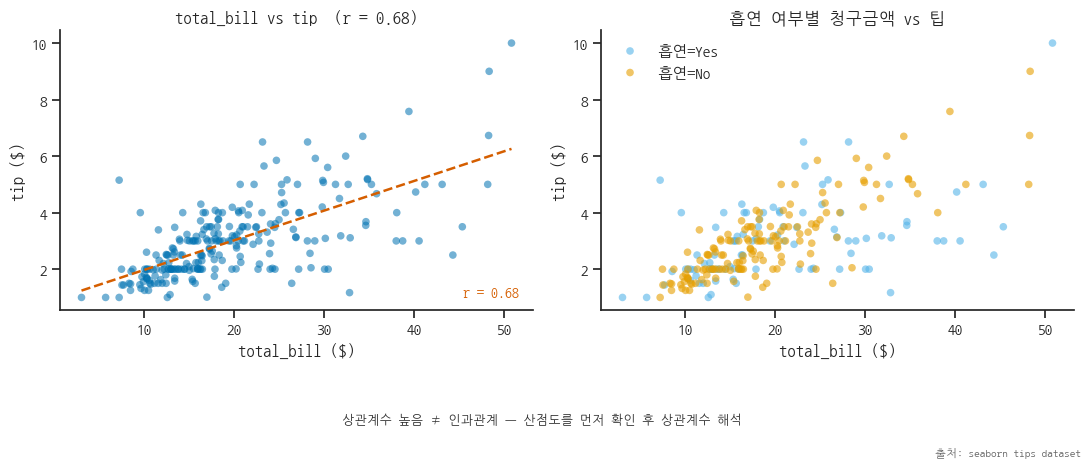

In [20]:
# ── 7. 두 변수 요약 — 산점도 · 공분산 · 상관계수 ─────────────────
"""
산점도(scatter plot): 두 연속형 변수 관계를 좌표평면에 표시
공분산 cov(x,y): 두 변수가 함께 변하는 방향과 크기 (단위 있음)
상관계수 r      = cov(x,y) / (sx × sy)  → -1 ~ +1 (단위 없음)
  r > 0: 정비례, r < 0: 반비례, r ≈ 0: 선형관계 없음
주의: 상관계수가 높다 ≠ 인과관계
"""

x = tips["total_bill"]
y = tips["tip"]

cov_val = np.cov(x, y, ddof=1)[0, 1]
r_val   = np.corrcoef(x, y)[0, 1]

print(f"공분산 cov(total_bill, tip) : {cov_val:.4f}")
print(f"상관계수 r                  : {r_val:.4f}")
print(f"→ 청구금액이 높을수록 팁도 많은 경향 (양의 상관, r≈{r_val:.2f})")
print()
print("=== 수치형 변수 전체 상관계수 행렬 ===")
print(tips[["total_bill","tip","size"]].corr().round(3))

# ── 시각화: 산점도 + 그룹별 색상 ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 왼쪽: 기본 산점도 + 추세선
axes[0].scatter(x, y, color=COLOR_SEQ, alpha=0.55, s=30, edgecolors="none")
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 200)
axes[0].plot(xline, m * xline + b, color=COLOR_EMPHASIS, lw=1.8, ls="--")
axes[0].set_xlabel("total_bill ($)")
axes[0].set_ylabel("tip ($)")
axes[0].set_title(f"total_bill vs tip  (r = {r_val:.2f})")
axes[0].text(0.97, 0.05, f"r = {r_val:.2f}", transform=axes[0].transAxes,
             ha="right", fontsize=10, color=COLOR_EMPHASIS)
spine_clean(axes[0])

# 오른쪽: 흡연 여부 색 구분
for smoker, grp in tips.groupby("smoker"):
    axes[1].scatter(grp["total_bill"], grp["tip"],
                    color=COLOR_BY_SMOKER[smoker], alpha=0.6, s=30,
                    label=f"흡연={smoker}", edgecolors="none")
axes[1].set_xlabel("total_bill ($)")
axes[1].set_ylabel("tip ($)")
axes[1].set_title("흡연 여부별 청구금액 vs 팁")
axes[1].legend(frameon=False)
spine_clean(axes[1])

add_footer(fig,
           caption="상관계수 높음 ≠ 인과관계 — 산점도를 먼저 확인 후 상관계수 해석",
           tight_rect=[0, 0.18, 1, 0.95])
plt.show()